# Dynamical System Analysis of Quantum Tunneling in an Asymmetric Double-Well Potential : Figures 7 and 8

**Authors:**  
Swetamber Das (ORCID: 0000-0002-2669-0842) <swetamber.p@srmap.edu.in>  
Arghya Dutta (ORCID: 0000-0003-2116-6475) <arghya.d@srmap.edu.in>  
Department of Physics, SRM University-AP, Amaravati 522240, Andhra Pradesh, India

---
**About:** *This notebook reproduces the skewness and kurtosis analysis for the Schroedinger simulations corresponding to Figures 7 and 8 in the manuscript.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# Set Latex fonts
new_rc_params = {
    "text.usetex": True,
    "figure.dpi": 400,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": "8",
    "font.family": "serif",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}
mpl.rcParams.update(new_rc_params)

In [3]:
def skewness_position(psi, x, dx):
    prob_density = np.abs(psi)**2

    mean_x = np.sum(x * prob_density) * dx
    variance = np.sum((x - mean_x)**2 * prob_density) * dx
    sigma = np.sqrt(variance)

    if sigma < 1e-14:
        return 0.0

    third_moment = np.sum((x - mean_x)**3 * prob_density) * dx
    return third_moment / sigma**3

In [4]:
def compute_skewness_vs_time(data):
    psi_data = data['psi_data']
    x = data['x']
    dt = data['dt']
    dx = x[1] - x[0]

    num_steps = psi_data.shape[0]
    times = np.arange(num_steps) * dt

    skewness_values = np.zeros(num_steps)

    for i in range(num_steps):
        skewness_values[i] = skewness_position(psi_data[i], x, dx)

    return times, skewness_values


In [5]:
# --------------------------------------------------
# Load datasets
# --------------------------------------------------
data1 = np.load("data/skewness-kurtosis-data/asymetric_double_well_left_well_13_6834.npz")
data2 = np.load("data/skewness-kurtosis-data/asymetric_double_well_right_well_13_6834.npz")
data3 = np.load("data/skewness-kurtosis-data/asymetric_double_well_left_well_19_6338.npz")
data4 = np.load("data/skewness-kurtosis-data/asymetric_double_well_right_well_19_6333.npz")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [6]:
# --------------------------------------------------
# Compute skewness
# --------------------------------------------------
t1, v1, s1, k1   = data1["times"], data1["variance"], data1["skewness"], data1["kurtosis"]
t2, v2, s2, k2   = data2["times"], data2["variance"], data2["skewness"], data2["kurtosis"]
t3, v3, s3, k3   = data3["times"], data3["variance"], data3["skewness"], data3["kurtosis"]
t4, v4, s4, k4   = data4["times"], data4["variance"], data4["skewness"], data4["kurtosis"]

print("Variance, Skewness, and Kurtosis data loaded.")

Variance, Skewness, and Kurtosis data loaded.


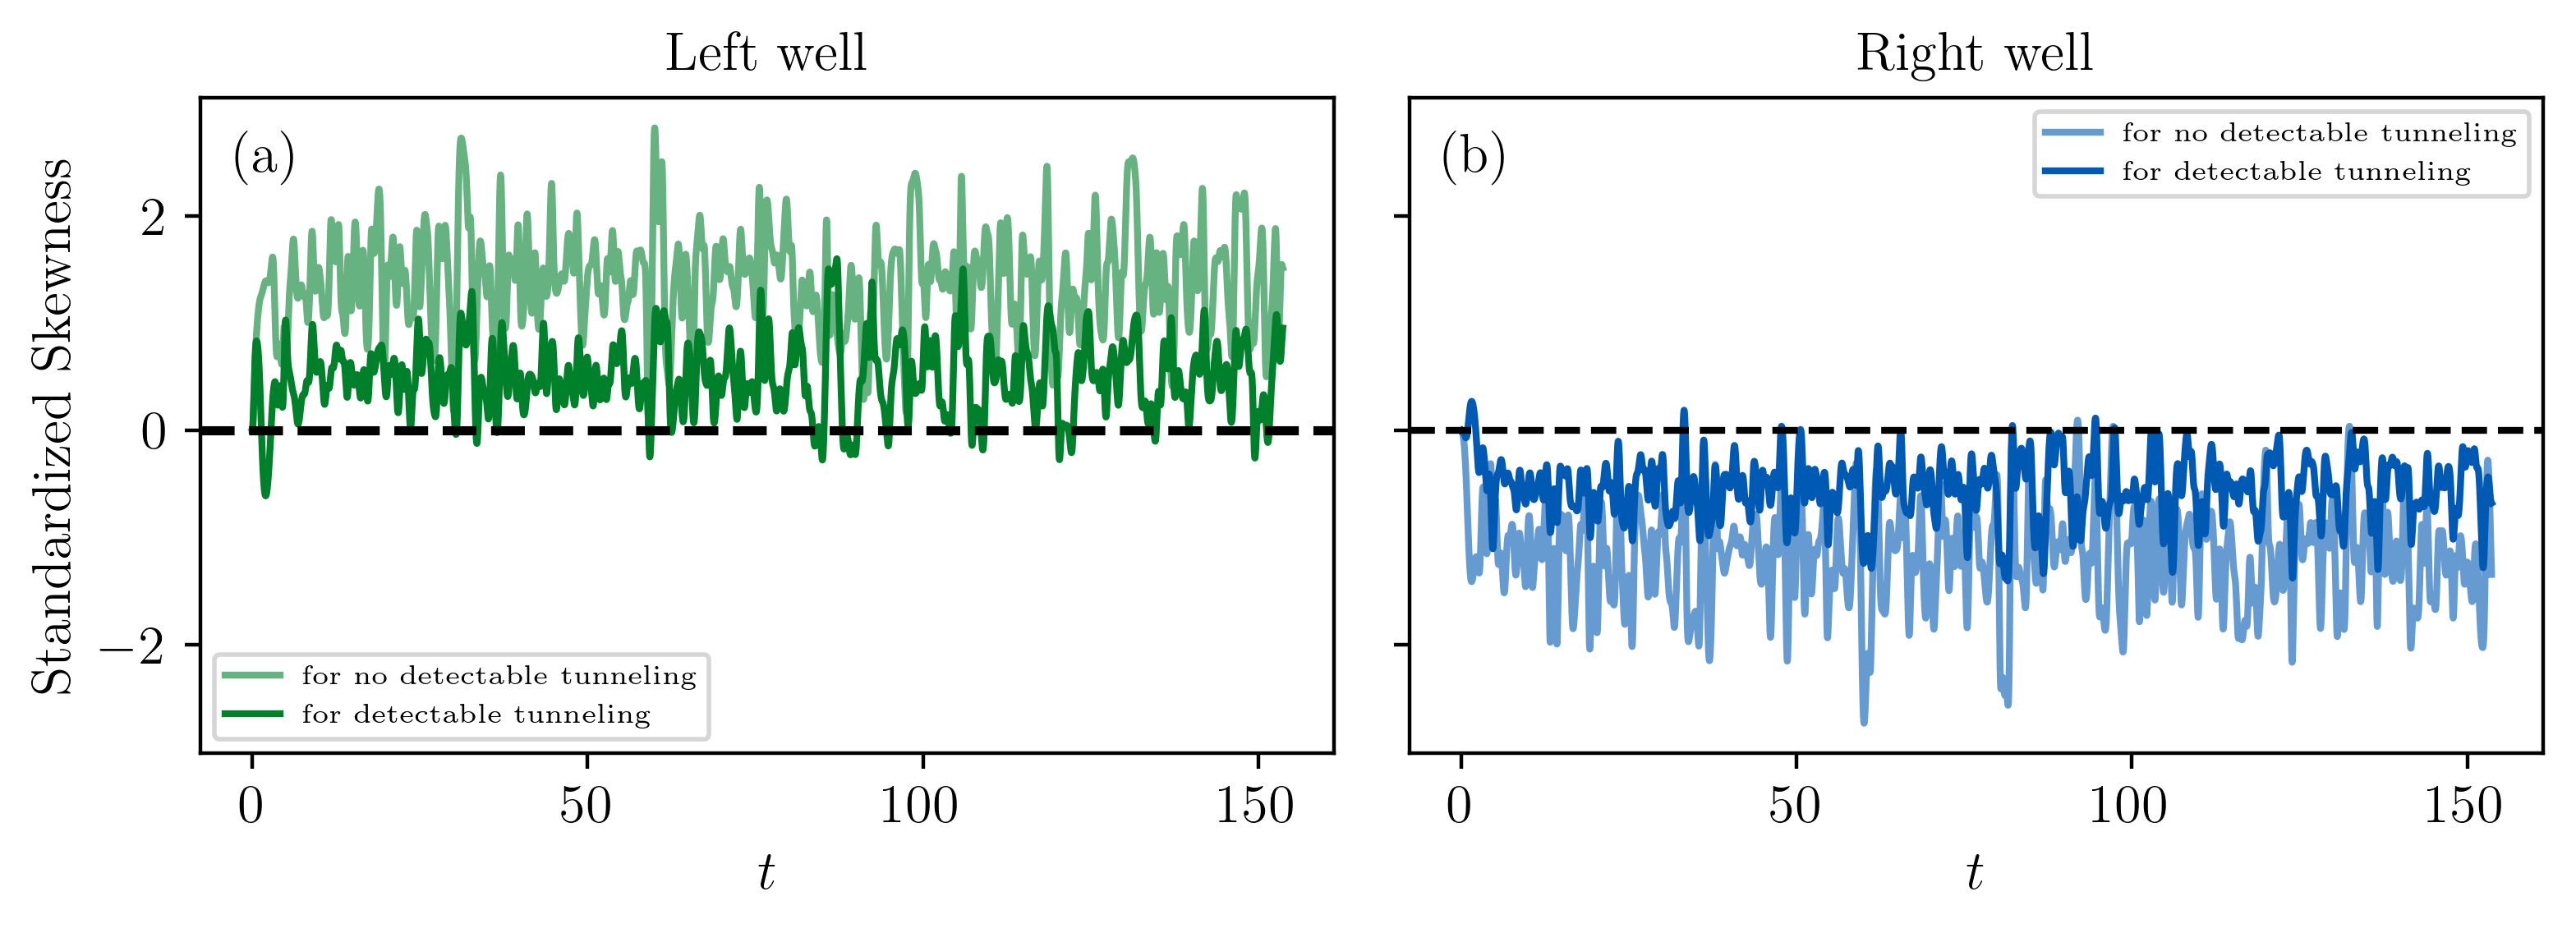

Plot saved as 'skewness_left_and_right_well.pdf'


In [7]:
# Style settings matched to time_series_plots_from_data.ipynb
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=12)
plt.rc('xtick', labelsize=12); plt.rc('ytick', labelsize=12)

# --------------------------------------------------
# Plot skewness in a 1x2 layout:
# Left panel = left-well cases, Right panel = right-well cases
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

# Left panel: left-well curves
axes[0].plot(t1, s1,
             color="#00802b", linestyle='-',
             linewidth=1.5,
             alpha = 0.6,
             label="for no detectable tunneling")
axes[0].plot(t3, s3,
             color="#00802b", linestyle='-',
             linewidth=1.5,
             label="for detectable tunneling")
axes[0].axhline(y=0.0, linestyle='--', linewidth=2, color="black")
axes[0].set_xlabel(r"$t$", fontsize=12)
axes[0].set_ylabel("Standardized Skewness", fontsize=12)
axes[0].set_title("Left well", fontsize=12)
axes[0].legend(fontsize=6)
axes[0].tick_params(labelsize=12)

# Right panel: right-well curves
axes[1].plot(t2, s2,
             color="#0059b3", linestyle='-',
             linewidth=1.5,
             alpha = 0.6,
             label="for no detectable tunneling")
axes[1].plot(t4, s4,
             color="#0059b3", linestyle='-',
             linewidth=1.5,
             label="for detectable tunneling")
axes[1].axhline(y=0.0, linestyle='--', linewidth=1.5, color="black")
axes[1].set_xlabel(r"$t$", fontsize=12)
axes[1].set_title("Right well", fontsize=12)
axes[1].legend(fontsize=6)
axes[1].tick_params(labelsize=12)

axes[0].text(0.03, 0.95, "(a)", transform=axes[0].transAxes, ha="left", va="top", fontsize=12)
axes[1].text(0.03, 0.95, "(b)", transform=axes[1].transAxes, ha="left", va="top", fontsize=12)

fig.tight_layout()
fig.savefig("fig7.pdf", dpi=600)
plt.show()

print("Plot saved as 'skewness_left_and_right_well.pdf'")


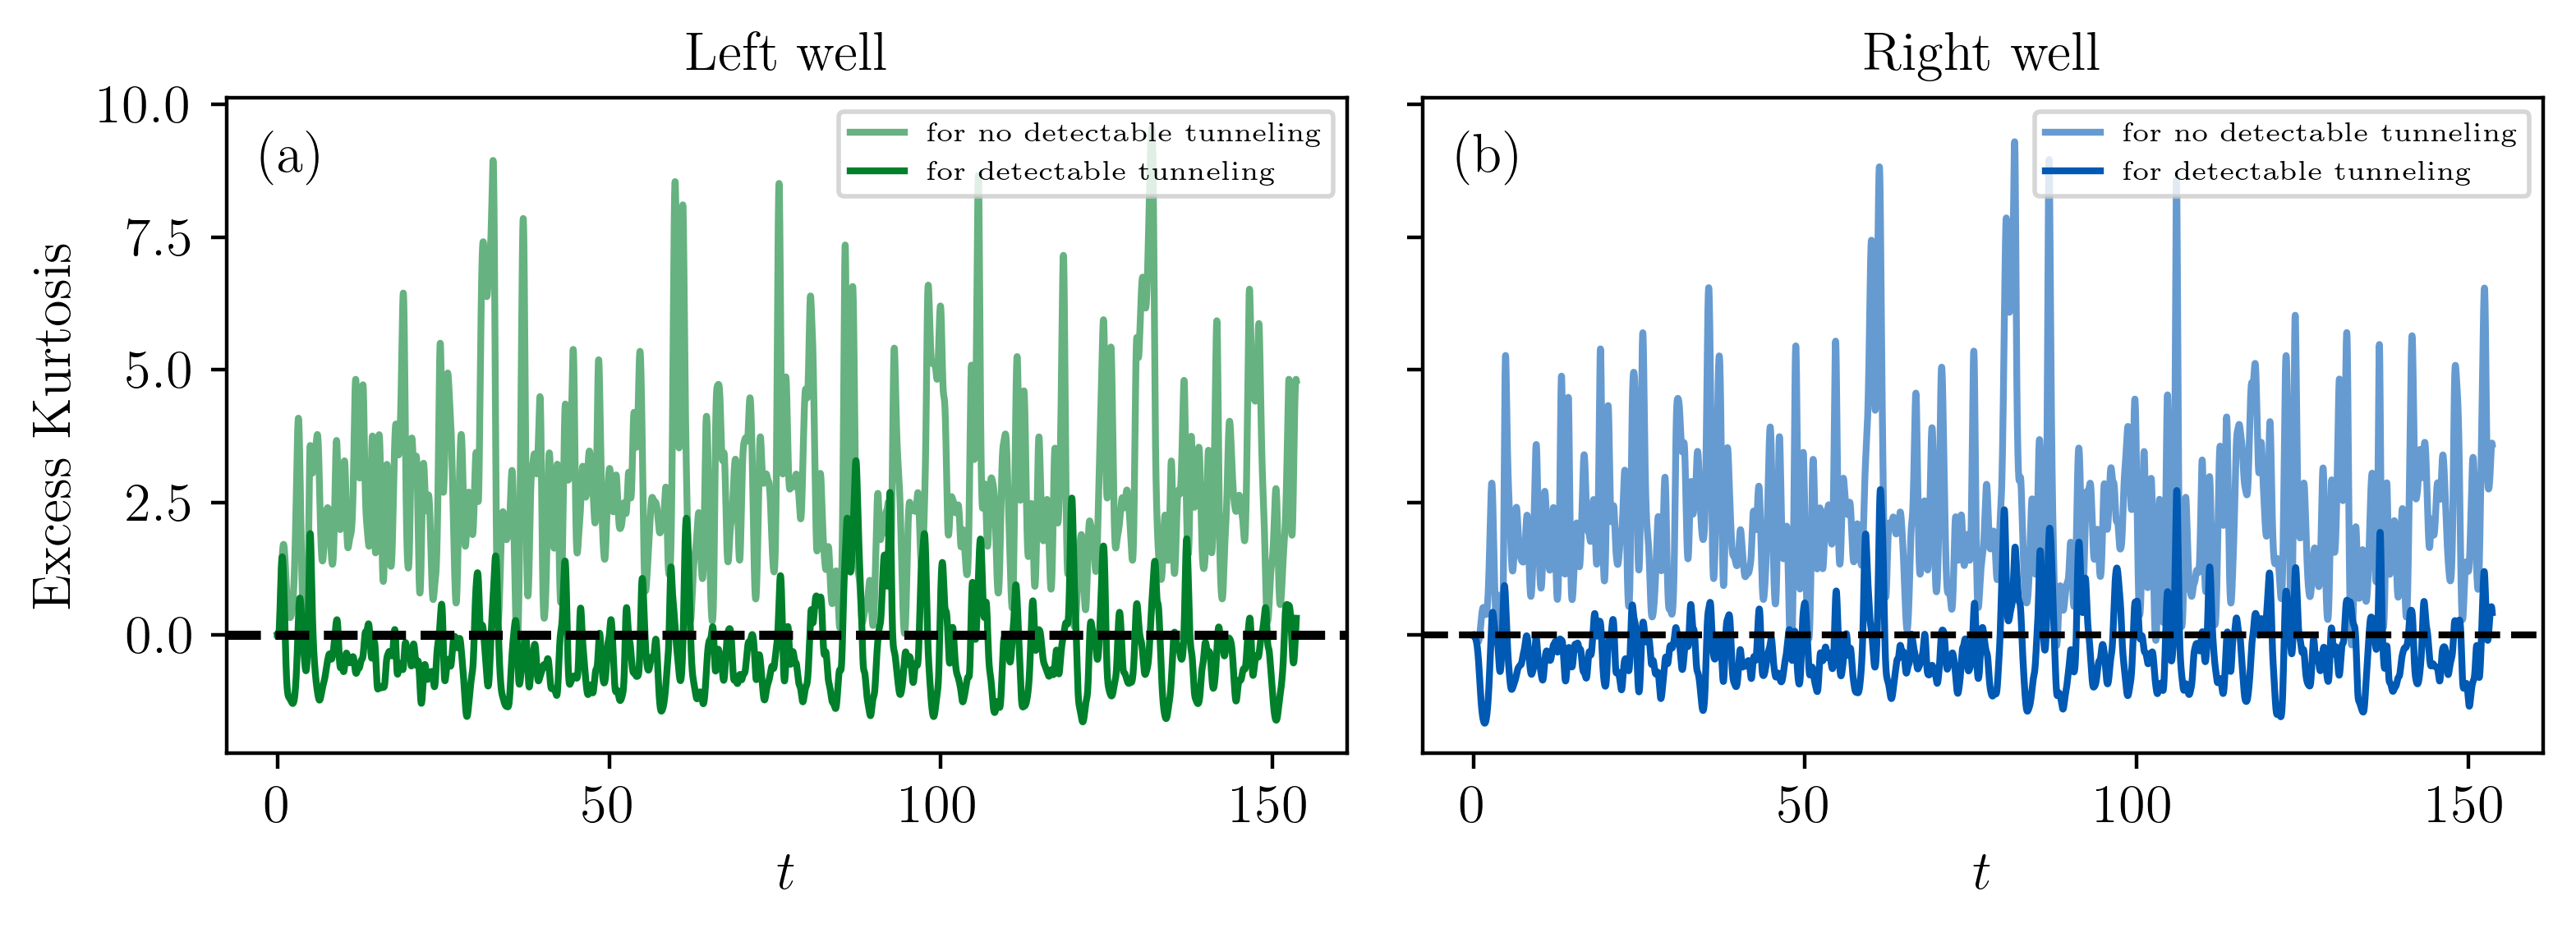

Plot saved as 'kurtosis_left_and_right_well.pdf'


In [8]:
# Style settings matched to time_series_plots_from_data.ipynb
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=12)
plt.rc('xtick', labelsize=12); plt.rc('ytick', labelsize=12)

# --------------------------------------------------
# Plot kurtosis in a 1x2 layout:
# Left panel = left-well cases, Right panel = right-well cases
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

# Left panel: left-well curves
axes[0].plot(t1, k1,
             color="#00802b", linestyle='-',
             linewidth=1.5,
             alpha = 0.6,
             label="for no detectable tunneling")
axes[0].plot(t3, k3,
             color="#00802b", linestyle='-',
             linewidth=1.5,
             label="for detectable tunneling")
axes[0].axhline(y=0.0, linestyle='--', linewidth=2, color="black")
axes[0].set_xlabel(r"$t$", fontsize=12)
axes[0].set_ylabel("Excess Kurtosis", fontsize=12)
axes[0].set_title("Left well", fontsize=12)
axes[0].legend(fontsize=6,loc='upper right')
axes[0].tick_params(labelsize=12)

# Right panel: right-well curves
axes[1].plot(t2, k2,
             color="#0059b3", linestyle='-',
             linewidth=1.5,
              alpha = 0.6,
             label="for no detectable tunneling")
axes[1].plot(t4, k4,
             color="#0059b3", linestyle='-',
             linewidth=1.5,
             label="for detectable tunneling")
axes[1].axhline(y=0.0, linestyle='--', linewidth=1.5, color="black")
axes[1].set_xlabel(r"$t$", fontsize=12)
axes[1].set_title("Right well", fontsize=12)
axes[1].legend(fontsize=6,loc='upper right')
axes[1].tick_params(labelsize=12)


axes[0].text(0.03, 0.95, "(a)", transform=axes[0].transAxes, ha="left", va="top", fontsize=12)
axes[1].text(0.03, 0.95, "(b)", transform=axes[1].transAxes, ha="left", va="top", fontsize=12)

fig.tight_layout()
fig.savefig("fig8.pdf", dpi=600)
plt.show()

print("Plot saved as 'kurtosis_left_and_right_well.pdf'")
